# Continuous Feature Engineering and Weight of Evidence

This notebook carries the discrete training and test checkpoints into the original fine- and coarse-classing workflow.

## Inputs and helpers

Fine-classing tables are calculated on training data. Coarse cut points are then applied unchanged to the held-out partition.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 100)
EPSILON = 1e-6
PROCESSED = Path("../data/processed")

In [2]:
inputs_train = pd.read_pickle(PROCESSED / "discrete_inputs_train.pkl")
inputs_test = pd.read_pickle(PROCESSED / "discrete_inputs_test.pkl")
target_train = pd.read_pickle(PROCESSED / "targets_train.pkl")
target_test = pd.read_pickle(PROCESSED / "targets_test.pkl")
inputs_train.shape, inputs_test.shape

((373028, 211), (93257, 211))

In [3]:
def _woe_table(inputs: pd.DataFrame, feature: str, target: pd.Series, ordered: bool) -> pd.DataFrame:
    """Build a WoE table; zero good/bad distributions are clipped to EPSILON before log."""
    frame = pd.concat([inputs[feature], target.rename("good_bad")], axis=1)
    table = frame.groupby(feature, dropna=False, observed=False)["good_bad"].agg(n_obs="count", prop_good="mean").reset_index()
    if ordered:
        table = table.sort_values(feature, na_position="last").reset_index(drop=True)
    table["prop_n_obs"] = table["n_obs"] / table["n_obs"].sum()
    table["n_good"] = table["n_obs"] * table["prop_good"]
    table["n_bad"] = table["n_obs"] - table["n_good"]
    table["prop_n_good"] = table["n_good"] / table["n_good"].sum()
    table["prop_n_bad"] = table["n_bad"] / table["n_bad"].sum()
    good_for_log = table["prop_n_good"].clip(lower=EPSILON)
    bad_for_log = table["prop_n_bad"].clip(lower=EPSILON)
    table["WoE"] = np.log(good_for_log / bad_for_log)
    table["diff_prop_good"] = table["prop_good"].diff().abs()
    table["diff_WoE"] = table["WoE"].diff().abs()
    table["IV"] = ((good_for_log - bad_for_log) * table["WoE"]).sum()
    return table


def woe_discrete(inputs: pd.DataFrame, feature: str, target: pd.Series) -> pd.DataFrame:
    """Return category counts, good/bad distributions, WoE, and feature IV."""
    return _woe_table(inputs, feature, target, ordered=False).sort_values("WoE").reset_index(drop=True)


def woe_ordered_continuous(inputs: pd.DataFrame, feature: str, target: pd.Series) -> pd.DataFrame:
    """Return ordered-bin counts, good/bad distributions, WoE, and feature IV."""
    return _woe_table(inputs, feature, target, ordered=True)


def plot_by_woe(table: pd.DataFrame, rotation: int = 0) -> None:
    """Plot WoE in table order with readable labels."""
    plt.figure(figsize=(18, 6))
    plt.plot(table.iloc[:, 0].astype(str), table["WoE"], marker="o", linestyle="--", color="black")
    plt.xlabel(table.columns[0])
    plt.ylabel("Weight of Evidence")
    plt.title(f"Weight of Evidence by {table.columns[0]}")
    plt.xticks(rotation=rotation)
    plt.show()


def add_groups(frame: pd.DataFrame, feature: str, groups: dict[str, list[str]]) -> pd.DataFrame:
    result = frame.copy()
    values = result[feature].fillna("Missing")
    for label, members in groups.items():
        result[f"{feature}:{label}"] = values.isin(members).astype(int)
    return result

## Fine-classing procedure

The ordered helper retains the natural order of raw values or interval bins. Each fine-classing table and range-focused plot supports the original coarse grouping decision.

In [4]:
def fine_class_table(frame: pd.DataFrame, feature: str, bins: int = 50) -> pd.DataFrame:
    fine = pd.cut(frame[feature], bins=bins)
    return woe_ordered_continuous(pd.DataFrame({f"{feature}_factor": fine}, index=frame.index), f"{feature}_factor", target_train.loc[frame.index])

## Term and employment length

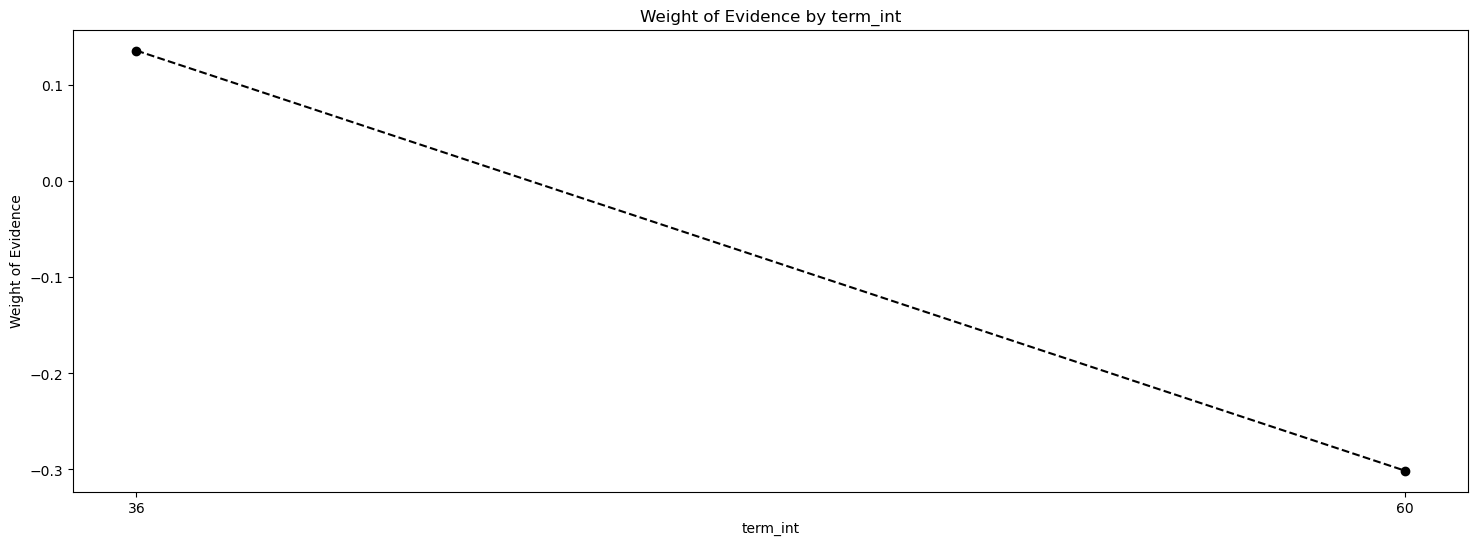

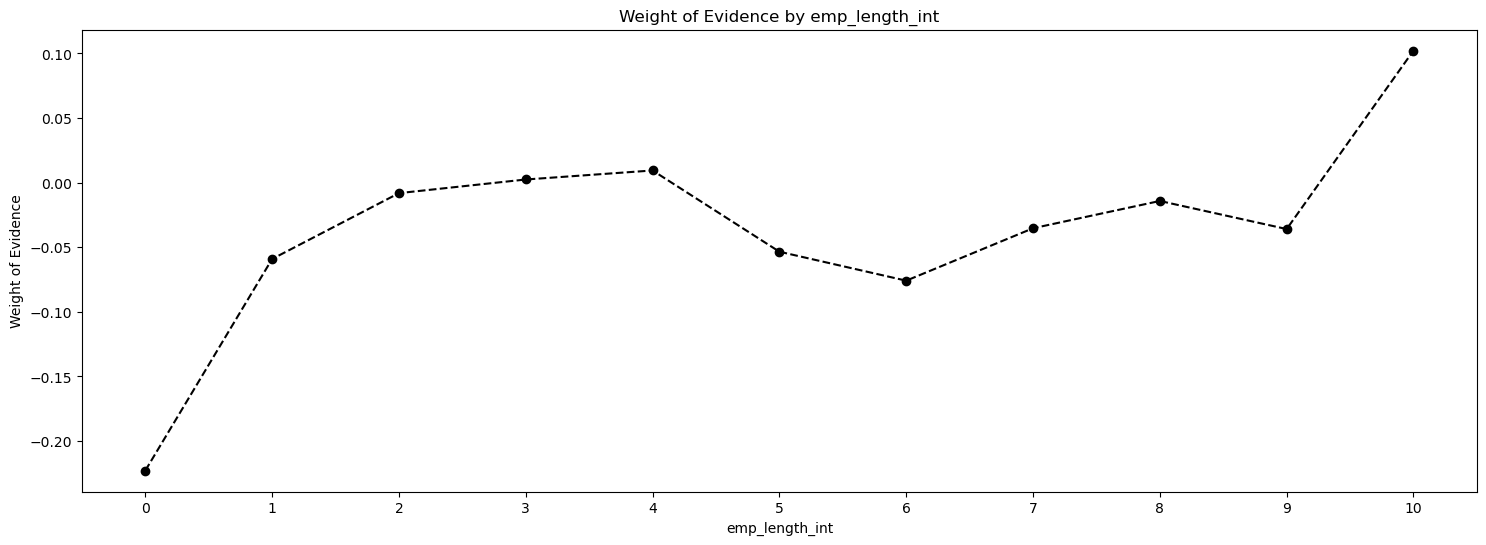

,term_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,36,270199,0.903238,0.72434,244054.0,26145.0,0.73454,0.641217,0.135876,NaN,NaN,0.040794
1,60,102829,0.857735,0.27566,88200.0,14629.0,0.26546,0.358783,-0.301254,0.045503,0.43713,0.040794


,emp_length_int,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0,16793,0.867028,0.045018,14560.0,2233.0,0.043822,0.054765,-0.222923,NaN,NaN,0.006841
1,1,52553,0.884802,0.140882,46499.0,6054.0,0.139950,0.148477,-0.059144,0.017774,0.163780,0.006841
2,2,33123,0.889895,0.088795,29476.0,3647.0,0.088715,0.089444,-0.008184,0.005093,0.050960,0.006841
3,3,29301,0.890925,0.078549,26105.0,3196.0,0.078569,0.078383,0.002372,0.001030,0.010555,0.006841
4,4,22482,0.891602,0.060269,20045.0,2437.0,0.060330,0.059768,0.009357,0.000677,0.006985,0.006841
5,5,24654,0.885374,0.066092,21828.0,2826.0,0.065697,0.069309,-0.053524,0.006229,0.062881,0.006841
6,6,21057,0.883079,0.056449,18595.0,2462.0,0.055966,0.060382,-0.075936,0.002294,0.022413,0.006841
7,7,20834,0.887204,0.055851,18484.0,2350.0,0.055632,0.057635,-0.035365,0.004124,0.040571,0.006841
8,8,17859,0.889300,0.047876,15882.0,1977.0,0.047801,0.048487,-0.014249,0.002096,0.021116,0.006841
9,9,14372,0.887142,0.038528,12750.0,1622.0,0.038374,0.039780,-0.035984,0.002158,0.021735,0.006841


In [5]:
term_woe = woe_ordered_continuous(inputs_train, "term_int", target_train)
emp_length_woe = woe_ordered_continuous(inputs_train, "emp_length_int", target_train)
plot_by_woe(term_woe)
plot_by_woe(emp_length_woe)
display(term_woe)
display(emp_length_woe)

In [6]:
def add_interval_groups(frame, feature, groups, output_feature=None):
    result = frame.copy()
    values = result[feature]
    for label, condition in groups.items():
        result[f"{output_feature or feature}:{label}"] = condition(values).astype(int)
    return result

term_groups = {"36": lambda x: x == 36, "60": lambda x: x == 60}
emp_length_groups = {"0": lambda x: x == 0, "1": lambda x: x == 1, "2-4": lambda x: x.between(2, 4), "5-6": lambda x: x.between(5, 6), "7-9": lambda x: x.between(7, 9), "10": lambda x: x == 10}

## Months since issue date

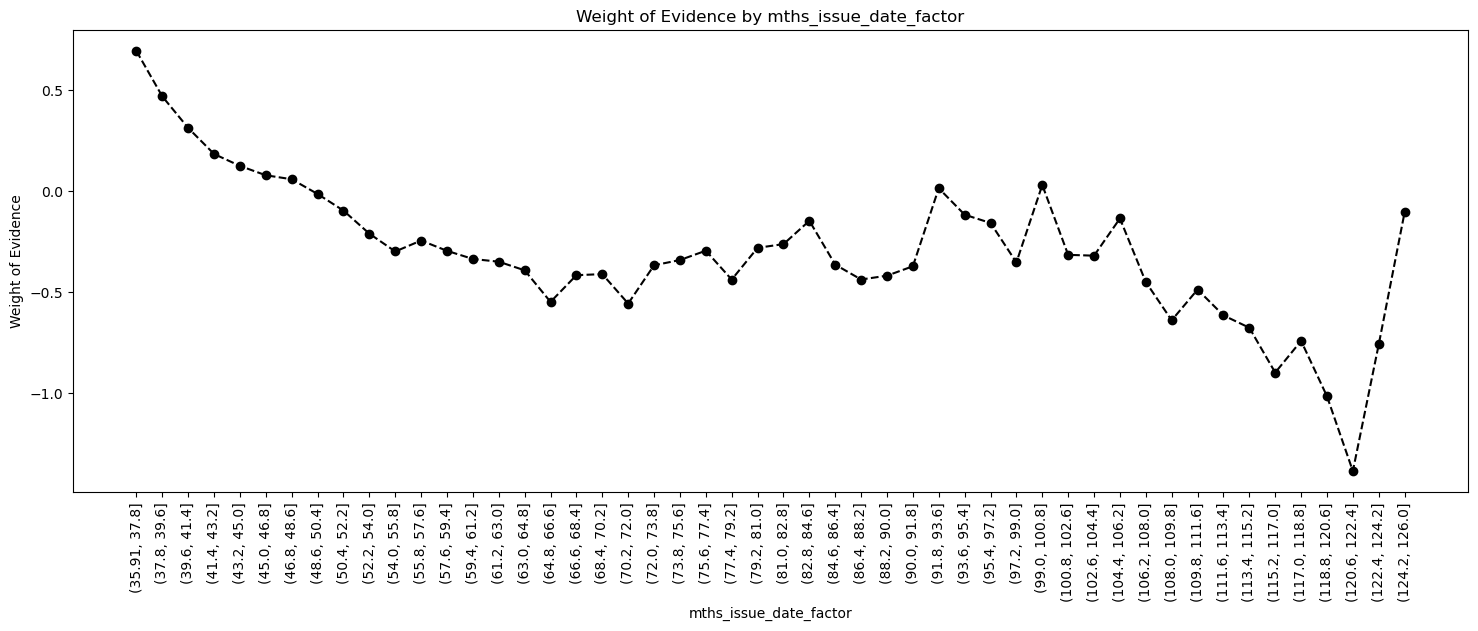

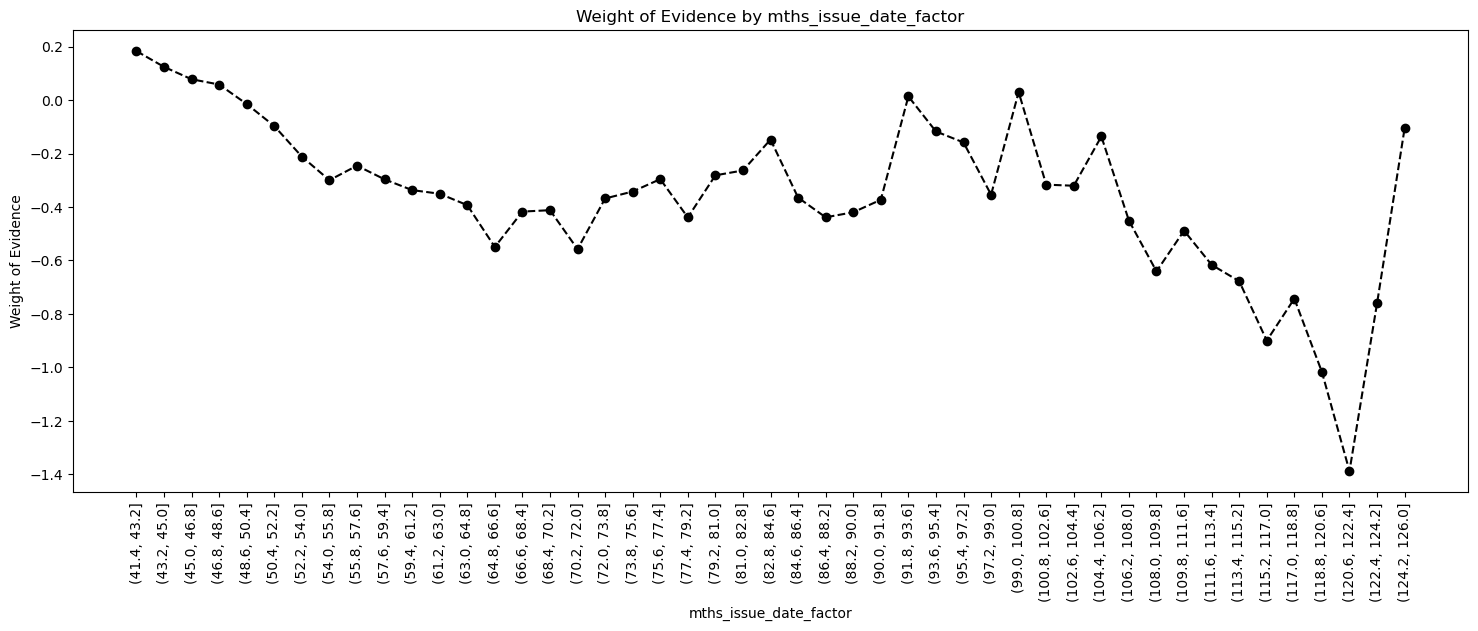

,mths_issue_date_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(35.91, 37.8]",28350,0.942187,0.076000,26711.0,1639.0,0.080393,0.040197,0.693134,NaN,NaN,0.111991
1,"(37.8, 39.6]",39515,0.928660,0.105930,36696.0,2819.0,0.110446,0.069137,0.468430,0.013527,0.224704,0.111991
2,"(39.6, 41.4]",38298,0.917594,0.102668,35142.0,3156.0,0.105768,0.077402,0.312236,0.011066,0.156194,0.111991
3,"(41.4, 43.2]",29136,0.907297,0.078107,26435.0,2701.0,0.079563,0.066243,0.183212,0.010297,0.129025,0.111991
4,"(43.2, 45.0]",28449,0.902211,0.076265,25667.0,2782.0,0.077251,0.068230,0.124181,0.005086,0.059031,0.111991
5,"(45.0, 46.8]",12231,0.898046,0.032788,10984.0,1247.0,0.033059,0.030583,0.077844,0.004165,0.046337,0.111991
6,"(46.8, 48.6]",24497,0.896232,0.065671,21955.0,2542.0,0.066079,0.062344,0.058189,0.001814,0.019655,0.111991
7,"(48.6, 50.4]",23122,0.889240,0.061985,20561.0,2561.0,0.061883,0.062810,-0.014857,0.006993,0.073045,0.111991
8,"(50.4, 52.2]",20565,0.880866,0.055130,18115.0,2450.0,0.054522,0.060087,-0.097203,0.008374,0.082346,0.111991
9,"(52.2, 54.0]",18305,0.868342,0.049071,15895.0,2410.0,0.047840,0.059106,-0.211477,0.012524,0.114274,0.111991


In [7]:
issue_fine = fine_class_table(inputs_train, "mths_issue_date")
plot_by_woe(issue_fine, rotation=90)
plot_by_woe(issue_fine.iloc[3:], rotation=90)
display(issue_fine)

In [8]:
issue_groups = {"<38": lambda x: x < 38, "38-39": lambda x: x.between(38, 39), "40-41": lambda x: x.between(40, 41), "42-48": lambda x: x.between(42, 48), "49-52": lambda x: x.between(49, 52), "53-64": lambda x: x.between(53, 64), "65-84": lambda x: x.between(65, 84), ">84": lambda x: x > 84}

## Interest rate and funded amount

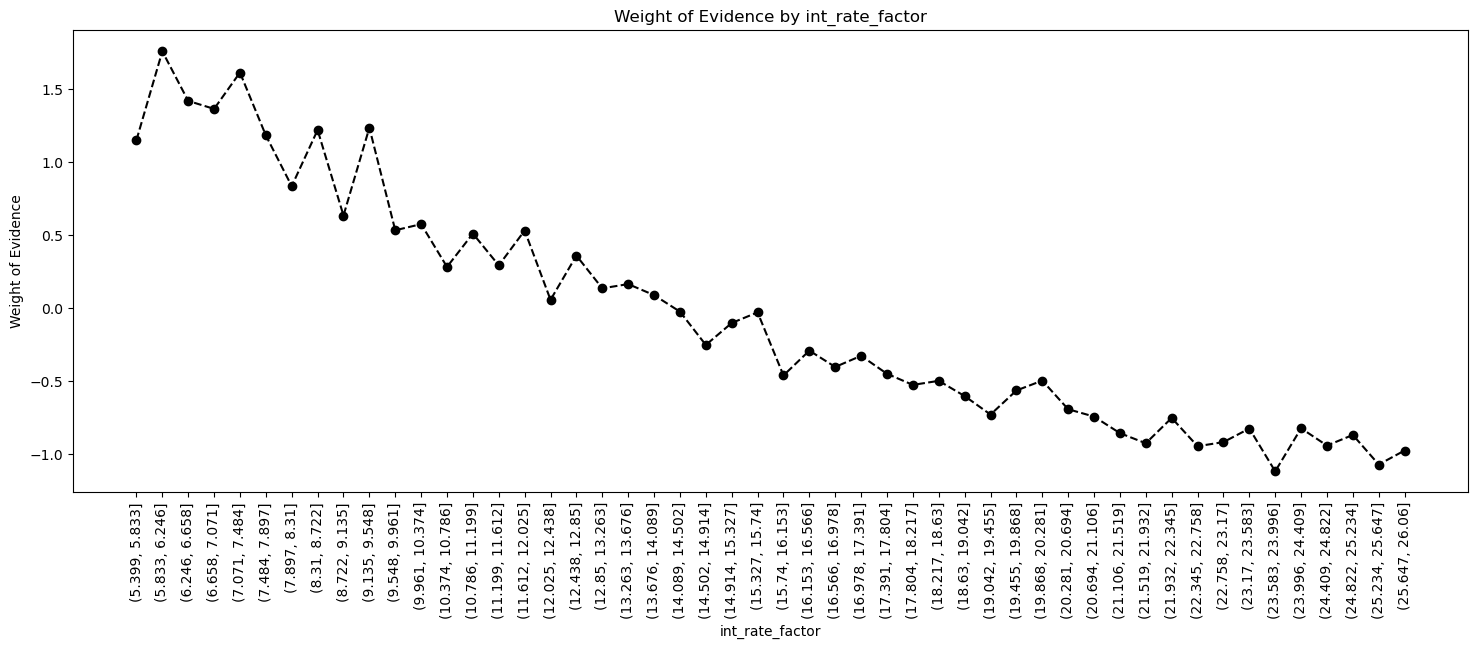

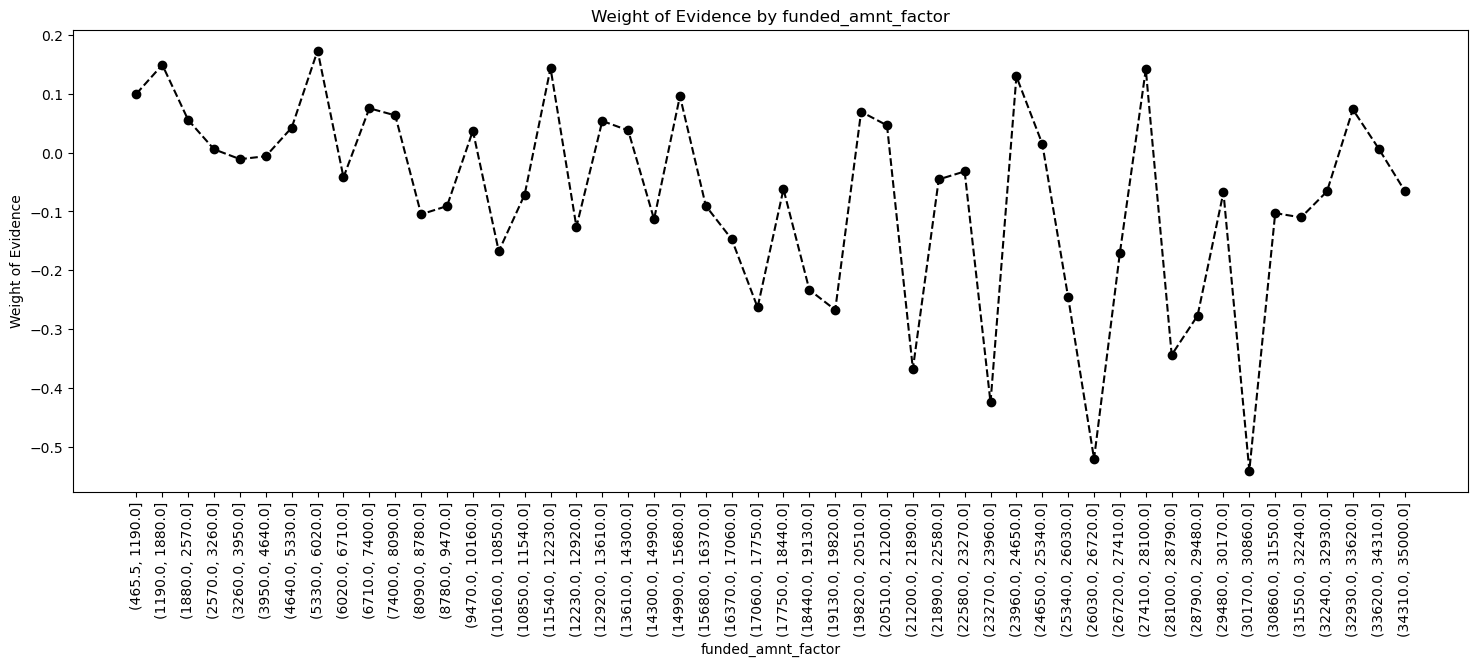

,int_rate_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(5.399, 5.833]",776,0.962629,0.002080,747.0,29.0,0.002248,0.000711,1.150914,NaN,NaN,0.346603
1,"(5.833, 6.246]",8408,0.979305,0.022540,8234.0,174.0,0.024782,0.004267,1.759117,0.016677,0.608203,0.346603
2,"(6.246, 6.658]",7842,0.971181,0.021023,7616.0,226.0,0.022922,0.005543,1.419616,0.008125,0.339500,0.346603
3,"(6.658, 7.071]",1777,0.969612,0.004764,1723.0,54.0,0.005186,0.001324,1.364983,0.001569,0.054633,0.346603
4,"(7.071, 7.484]",3186,0.976146,0.008541,3110.0,76.0,0.009360,0.001864,1.613790,0.006534,0.248806,0.346603
5,"(7.484, 7.897]",12590,0.963781,0.033751,12134.0,456.0,0.036520,0.011184,1.183419,0.012365,0.430371,0.346603
6,"(7.897, 8.31]",9680,0.949483,0.025950,9191.0,489.0,0.027663,0.011993,0.835762,0.014297,0.347656,0.346603
7,"(8.31, 8.722]",6666,0.965047,0.017870,6433.0,233.0,0.019362,0.005714,1.220303,0.015563,0.384540,0.346603
8,"(8.722, 9.135]",9578,0.938923,0.025676,8993.0,585.0,0.027067,0.014347,0.634735,0.026124,0.585568,0.346603
9,"(9.135, 9.548]",6563,0.965565,0.017594,6337.0,226.0,0.019073,0.005543,1.235771,0.026642,0.601036,0.346603


,funded_amnt_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(465.5, 1190.0]",1241,0.900081,0.003327,1117.0,124.0,0.003362,0.003041,0.100265,NaN,NaN,0.014394
1,"(1190.0, 1880.0]",3086,0.904407,0.008273,2791.0,295.0,0.008400,0.007235,0.149325,0.004326,0.049060,0.014394
2,"(1880.0, 2570.0]",6047,0.895981,0.016211,5418.0,629.0,0.016307,0.015426,0.055496,0.008426,0.093829,0.014394
3,"(2570.0, 3260.0]",7255,0.891247,0.019449,6466.0,789.0,0.019461,0.019351,0.005692,0.004734,0.049804,0.014394
4,"(3260.0, 3950.0]",4756,0.889613,0.012750,4231.0,525.0,0.012734,0.012876,-0.011060,0.001634,0.016751,0.014394
5,"(3950.0, 4640.0]",9054,0.890104,0.024272,8059.0,995.0,0.024256,0.024403,-0.006053,0.000491,0.005007,0.014394
6,"(4640.0, 5330.0]",15927,0.894770,0.042697,14251.0,1676.0,0.042892,0.041105,0.042562,0.004666,0.048615,0.014394
7,"(5330.0, 6020.0]",17206,0.906486,0.046125,15597.0,1609.0,0.046943,0.039461,0.173611,0.011716,0.131049,0.014394
8,"(6020.0, 6710.0]",6910,0.886541,0.018524,6126.0,784.0,0.018438,0.019228,-0.041967,0.019945,0.215577,0.014394
9,"(6710.0, 7400.0]",11745,0.897829,0.031486,10545.0,1200.0,0.031738,0.029431,0.075475,0.011288,0.117442,0.014394


In [9]:
int_rate_fine = fine_class_table(inputs_train, "int_rate")
funded_amnt_fine = fine_class_table(inputs_train, "funded_amnt")
plot_by_woe(int_rate_fine, rotation=90)
plot_by_woe(funded_amnt_fine, rotation=90)
display(int_rate_fine)
display(funded_amnt_fine)

In [10]:
int_rate_groups = {"<9.548": lambda x: x <= 9.548, "9.548-12.025": lambda x: x.gt(9.548) & x.le(12.025), "12.025-15.74": lambda x: x.gt(12.025) & x.le(15.74), "15.74-20.281": lambda x: x.gt(15.74) & x.le(20.281), ">20.281": lambda x: x > 20.281}

**Funded amount conclusion.** The original fine-classing plot is retained, but no funded-amount dummy family is added: it does not show useful monotonic discriminatory structure for this model.

## Months since earliest credit line and installment

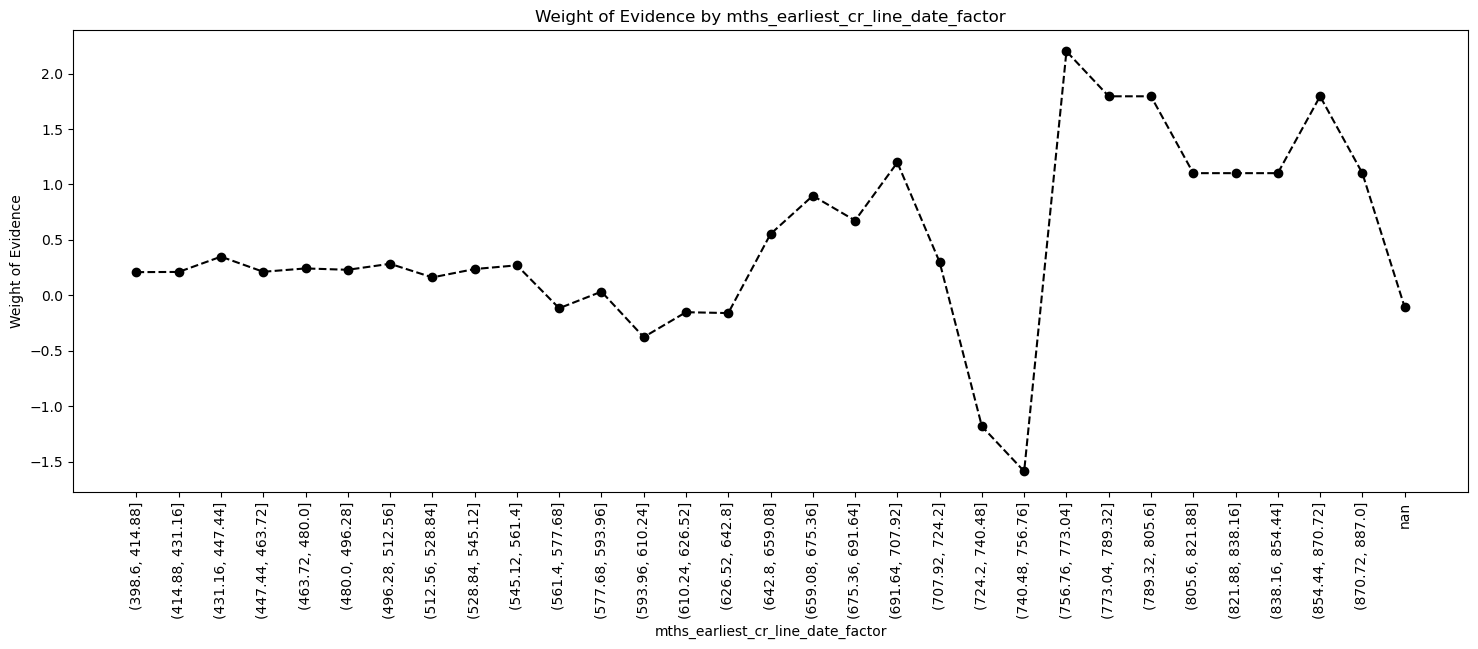

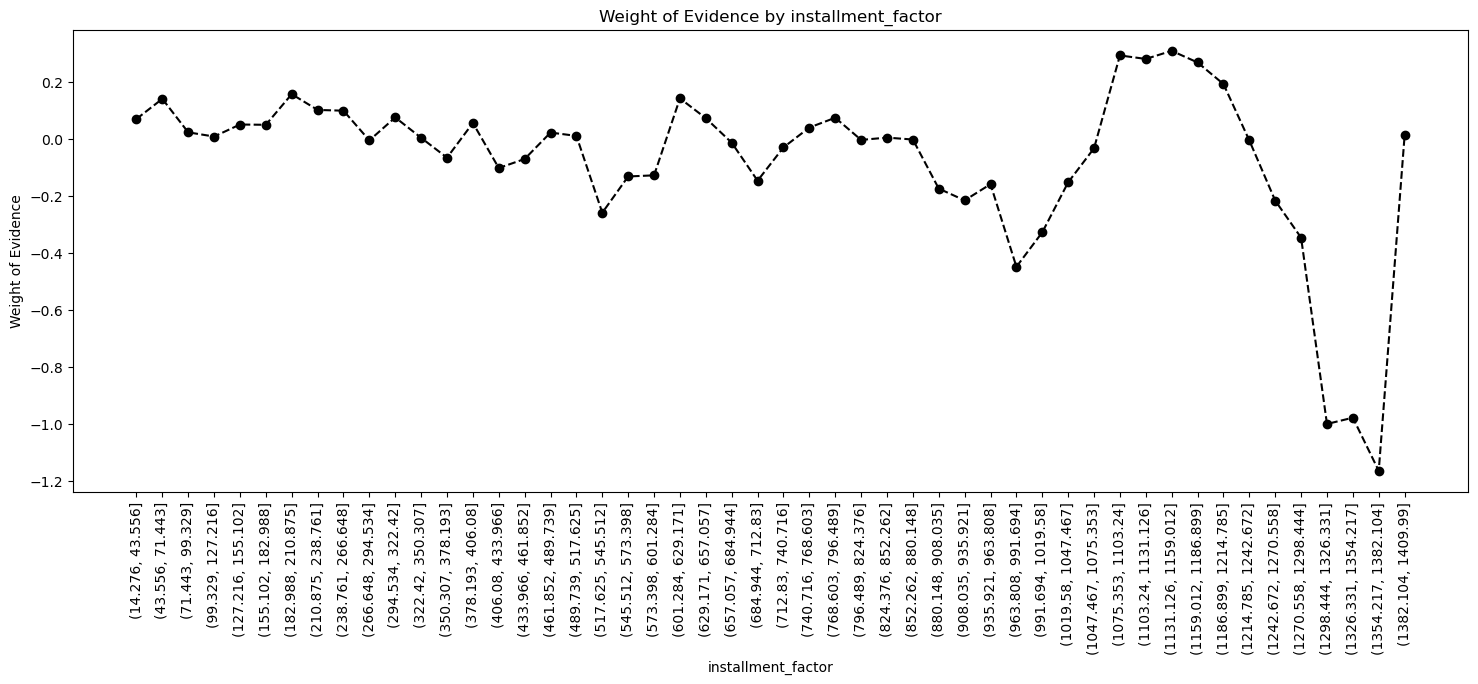

,mths_earliest_cr_line_date_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(72.186, 89.28]",1967,0.904423,0.005273,1779.0,188.0,0.005354,0.004611,0.149510,NaN,NaN,0.017658
1,"(89.28, 105.56]",3521,0.855723,0.009439,3013.0,508.0,0.009068,0.012459,-0.317645,0.048700,0.467155,0.017658
2,"(105.56, 121.84]",7572,0.871500,0.020299,6599.0,973.0,0.019861,0.023863,-0.183566,0.015777,0.134079,0.017658
3,"(121.84, 138.12]",16441,0.861991,0.044074,14172.0,2269.0,0.042654,0.055648,-0.265926,0.009509,0.082360,0.017658
4,"(138.12, 154.4]",17516,0.876056,0.046956,15345.0,2171.0,0.046185,0.053245,-0.142253,0.014065,0.123673,0.017658
5,"(154.4, 170.68]",23240,0.879776,0.062301,20446.0,2794.0,0.061537,0.068524,-0.107542,0.003720,0.034711,0.017658
6,"(170.68, 186.96]",28952,0.888609,0.077613,25727.0,3225.0,0.077432,0.079095,-0.021247,0.008832,0.086295,0.017658
7,"(186.96, 203.24]",36357,0.883709,0.097465,32129.0,4228.0,0.096700,0.103694,-0.069825,0.004900,0.048578,0.017658
8,"(203.24, 219.52]",38700,0.886537,0.103746,34309.0,4391.0,0.103261,0.107691,-0.042004,0.002829,0.027821,0.017658
9,"(219.52, 235.8]",32076,0.887018,0.085988,28452.0,3624.0,0.085633,0.088880,-0.037215,0.000481,0.004789,0.017658


,installment_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(14.276, 43.556]",1841,0.897338,0.004935,1652.0,189.0,0.004972,0.004635,0.070140,NaN,NaN,0.012927
1,"(43.556, 71.443]",4889,0.903661,0.013106,4418.0,471.0,0.013297,0.011551,0.140729,0.006323,0.070589,0.012927
2,"(71.443, 99.329]",6875,0.892945,0.018430,6139.0,736.0,0.018477,0.018051,0.023332,0.010716,0.117397,0.012927
3,"(99.329, 127.216]",9145,0.891525,0.024516,8153.0,992.0,0.024538,0.024329,0.008563,0.001420,0.014769,0.012927
4,"(127.216, 155.102]",10099,0.895534,0.027073,9044.0,1055.0,0.027220,0.025874,0.050706,0.004009,0.042143,0.012927
5,"(155.102, 182.988]",16786,0.895449,0.044999,15031.0,1755.0,0.045239,0.043042,0.049791,0.000086,0.000915,0.012927
6,"(182.988, 210.875]",17047,0.905086,0.045699,15429.0,1618.0,0.046437,0.039682,0.157203,0.009637,0.107412,0.012927
7,"(210.875, 238.761]",15114,0.900225,0.040517,13606.0,1508.0,0.040951,0.036984,0.101871,0.004861,0.055331,0.012927
8,"(238.761, 266.648]",18717,0.899984,0.050176,16845.0,1872.0,0.050699,0.045912,0.099191,0.000241,0.002680,0.012927
9,"(266.648, 294.534]",20121,0.890214,0.053940,17912.0,2209.0,0.053911,0.054177,-0.004924,0.009770,0.104116,0.012927


In [11]:
earliest_fine = fine_class_table(inputs_train, "mths_earliest_cr_line_date")
installment_fine = fine_class_table(inputs_train, "installment")
plot_by_woe(earliest_fine.iloc[20:], rotation=90)
plot_by_woe(installment_fine, rotation=90)
display(earliest_fine)
display(installment_fine)

In [12]:
earliest_groups = {"Missing_or_<140": lambda x: x.isna() | x.lt(140), "140-164": lambda x: x.between(140, 164), "165-247": lambda x: x.between(165, 247), "248-270": lambda x: x.between(248, 270), "271-352": lambda x: x.between(271, 352), ">352": lambda x: x > 352}

## Delinquencies, inquiries, open accounts, and public records

,delinq_2yrs,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,306431,0.890758,0.821469,272956.0,33475.0,0.821528,0.820989,0.000657,NaN,NaN,0.000553
1,1.0,44972,0.891888,0.120559,40110.0,4862.0,0.120721,0.119243,0.012321,0.001130,0.011664,0.000553
2,2.0,13056,0.887178,0.035000,11583.0,1473.0,0.034862,0.036126,-0.035618,0.004710,0.047938,0.000553
3,3.0,4510,0.882262,0.012090,3979.0,531.0,0.011976,0.013023,-0.083831,0.004917,0.048214,0.000553
4,4.0,1895,0.900792,0.005080,1707.0,188.0,0.005138,0.004611,0.108196,0.018530,0.192027,0.000553
5,5.0,990,0.887879,0.002654,879.0,111.0,0.002646,0.002722,-0.028600,0.012913,0.136796,0.000553
6,6.0,502,0.894422,0.001346,449.0,53.0,0.001351,0.001300,0.038876,0.006544,0.067476,0.000553
7,7.0,285,0.877193,0.000764,250.0,35.0,0.000752,0.000858,-0.131742,0.017229,0.170618,0.000553
8,8.0,145,0.917241,0.000389,133.0,12.0,0.000400,0.000294,0.307587,0.040048,0.439330,0.000553
9,9.0,83,0.867470,0.000223,72.0,11.0,0.000217,0.000270,-0.219084,0.049771,0.526672,0.000553


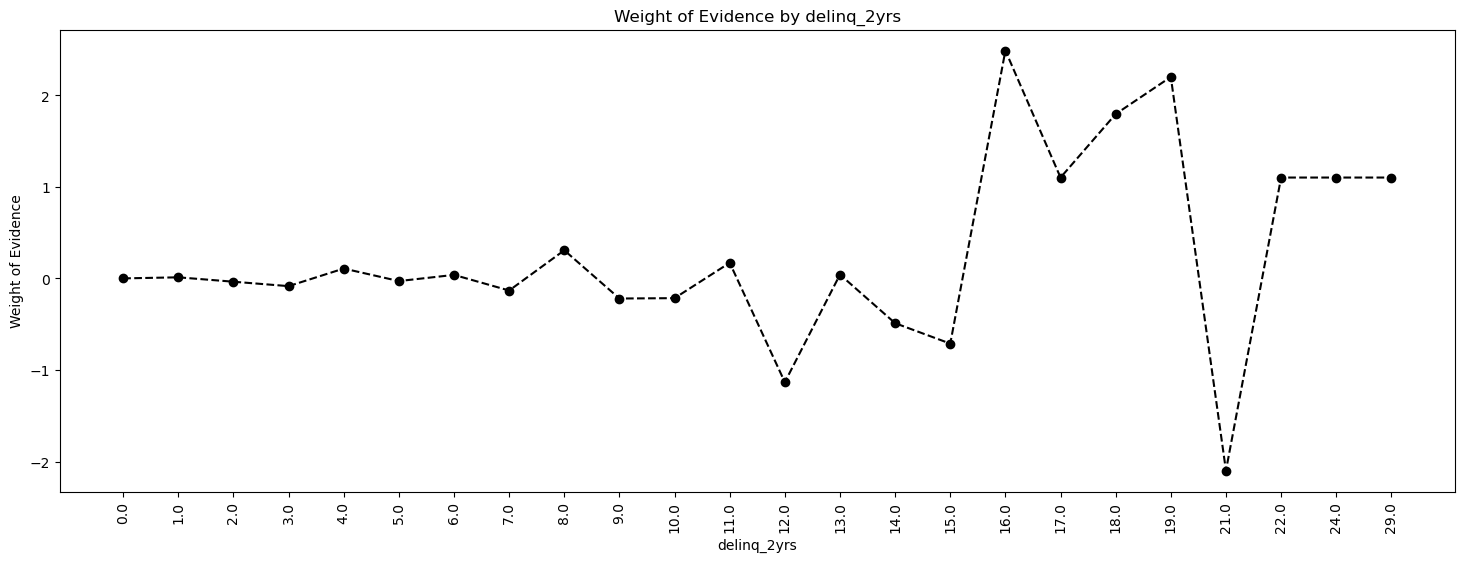

,inq_last_6mths,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,193187,0.908570,0.517889,175524.0,17663.0,0.528283,0.433193,0.198449,NaN,NaN,0.051827
1,1.0,104049,0.884814,0.278931,92064.0,11985.0,0.277089,0.293937,-0.059027,0.023757,0.257476,0.051827
2,2.0,46361,0.863679,0.124283,40041.0,6320.0,0.120513,0.155001,-0.251670,0.021135,0.192643,0.051827
3,3.0,20110,0.841174,0.053910,16916.0,3194.0,0.050913,0.078334,-0.430869,0.022505,0.179199,0.051827
4,4.0,5772,0.845807,0.015473,4882.0,890.0,0.014694,0.021828,-0.395766,0.004634,0.035103,0.051827
5,5.0,2218,0.825068,0.005946,1830.0,388.0,0.005508,0.009516,-0.546789,0.020740,0.151023,0.051827
6,6.0,960,0.792708,0.002574,761.0,199.0,0.002290,0.004881,-0.756527,0.032359,0.209737,0.051827
7,7.0,153,0.633987,0.000410,97.0,56.0,0.000292,0.001373,-1.548496,0.158721,0.791969,0.051827
8,8.0,98,0.632653,0.000263,62.0,36.0,0.000187,0.000883,-1.554240,0.001334,0.005744,0.051827
9,9.0,41,0.609756,0.000110,25.0,16.0,0.000075,0.000392,-1.651568,0.022897,0.097328,0.051827


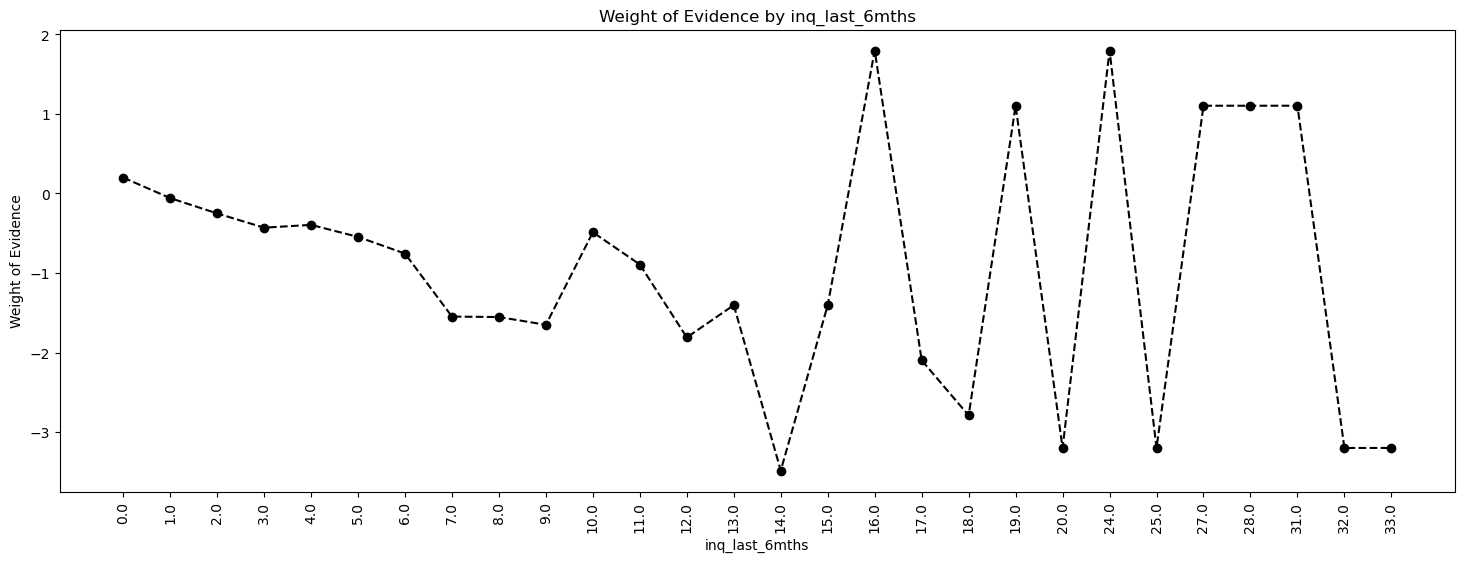

,open_acc,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,32,0.781250,0.000086,25.0,7.0,0.000075,0.000172,-0.824889,NaN,NaN,0.002804
1,1.0,107,0.887850,0.000287,95.0,12.0,0.000286,0.000294,-0.028885,0.106600,0.796005,0.002804
2,2.0,1447,0.847270,0.003879,1226.0,221.0,0.003690,0.005420,-0.384506,0.040580,0.355621,0.002804
3,3.0,4426,0.869860,0.011865,3850.0,576.0,0.011588,0.014127,-0.198134,0.022590,0.186371,0.002804
4,4.0,10037,0.892199,0.026907,8955.0,1082.0,0.026952,0.026537,0.015546,0.022339,0.213680,0.002804
5,5.0,17224,0.891547,0.046173,15356.0,1868.0,0.046218,0.045814,0.008783,0.000652,0.006763,0.002804
6,6.0,24652,0.891773,0.066086,21984.0,2668.0,0.066166,0.065434,0.011131,0.000227,0.002348,0.002804
7,7.0,29912,0.890479,0.080187,26636.0,3276.0,0.080168,0.080345,-0.002215,0.001295,0.013345,0.002804
8,8.0,33510,0.891435,0.089832,29872.0,3638.0,0.089907,0.089224,0.007632,0.000957,0.009847,0.002804
9,9.0,35148,0.889041,0.094223,31248.0,3900.0,0.094049,0.095649,-0.016876,0.002395,0.024509,0.002804


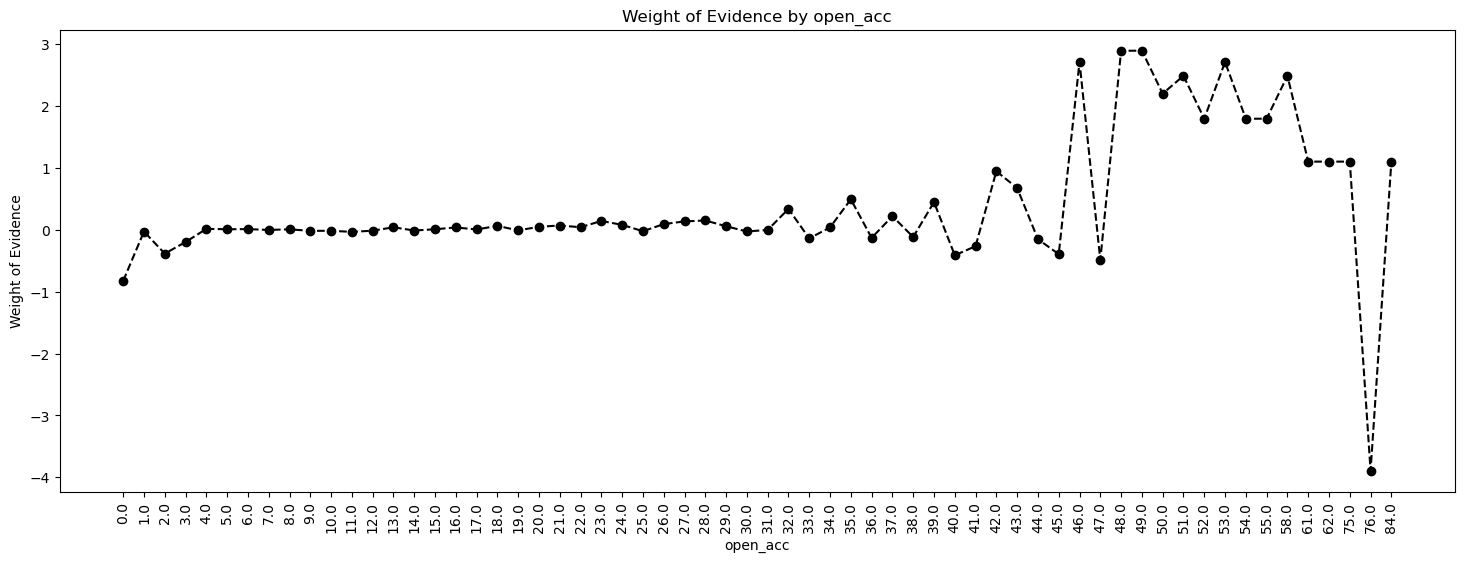

,pub_rec,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,323916,0.889678,0.868342,288181.0,35735.0,0.867351,0.876416,-0.010397,NaN,NaN,0.001412
1,1.0,42470,0.895409,0.113852,38028.0,4442.0,0.114455,0.108942,0.049363,0.005730,0.059760,0.001412
2,2.0,4476,0.907060,0.011999,4060.0,416.0,0.012220,0.010203,0.180398,0.011651,0.131035,0.001412
3,3.0,1288,0.915373,0.003453,1179.0,109.0,0.003548,0.002673,0.283219,0.008313,0.102821,0.001412
4,4.0,430,0.909302,0.001153,391.0,39.0,0.001177,0.000956,0.207291,0.006070,0.075928,0.001412
5,5.0,236,0.906780,0.000633,214.0,22.0,0.000644,0.000540,0.177078,0.002523,0.030212,0.001412
6,6.0,111,0.945946,0.000298,105.0,6.0,0.000316,0.000147,0.764346,0.039166,0.587267,0.001412
7,7.0,44,0.954545,0.000118,42.0,2.0,0.000126,0.000049,0.946667,0.008600,0.182322,0.001412
8,8.0,23,0.956522,0.000062,22.0,1.0,0.000066,0.000025,0.993187,0.001976,0.046520,0.001412
9,9.0,13,0.846154,0.000035,11.0,2.0,0.000033,0.000049,-0.393107,0.110368,1.386294,0.001412


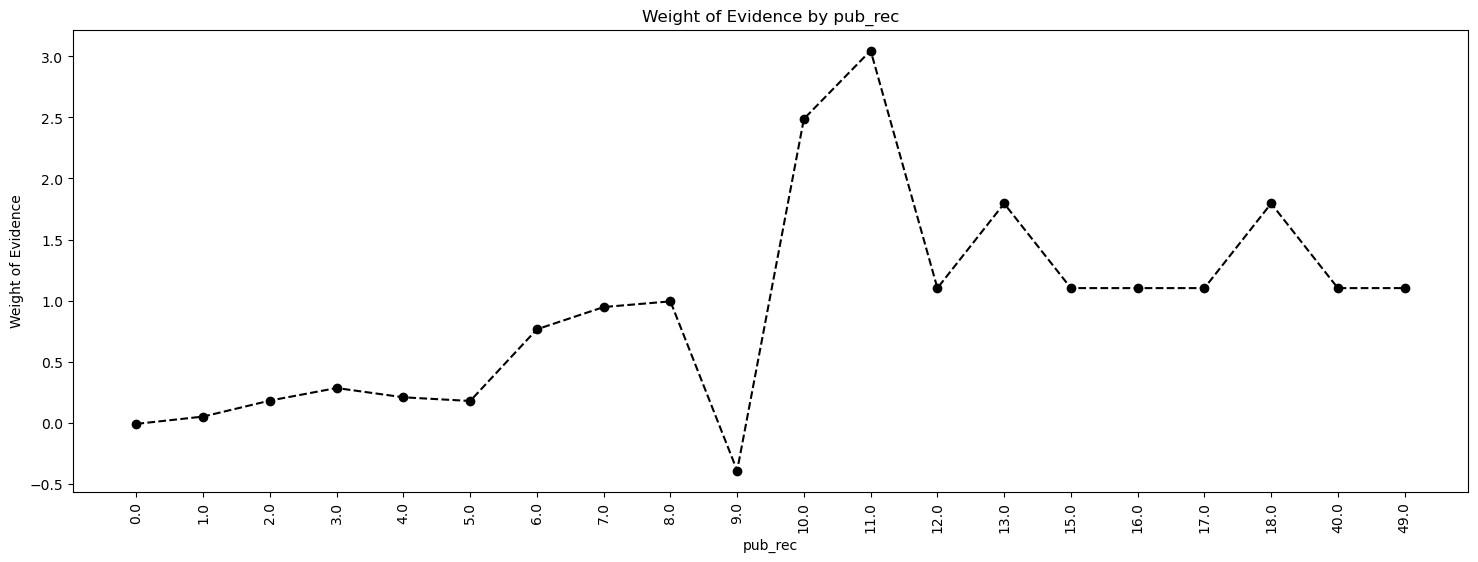

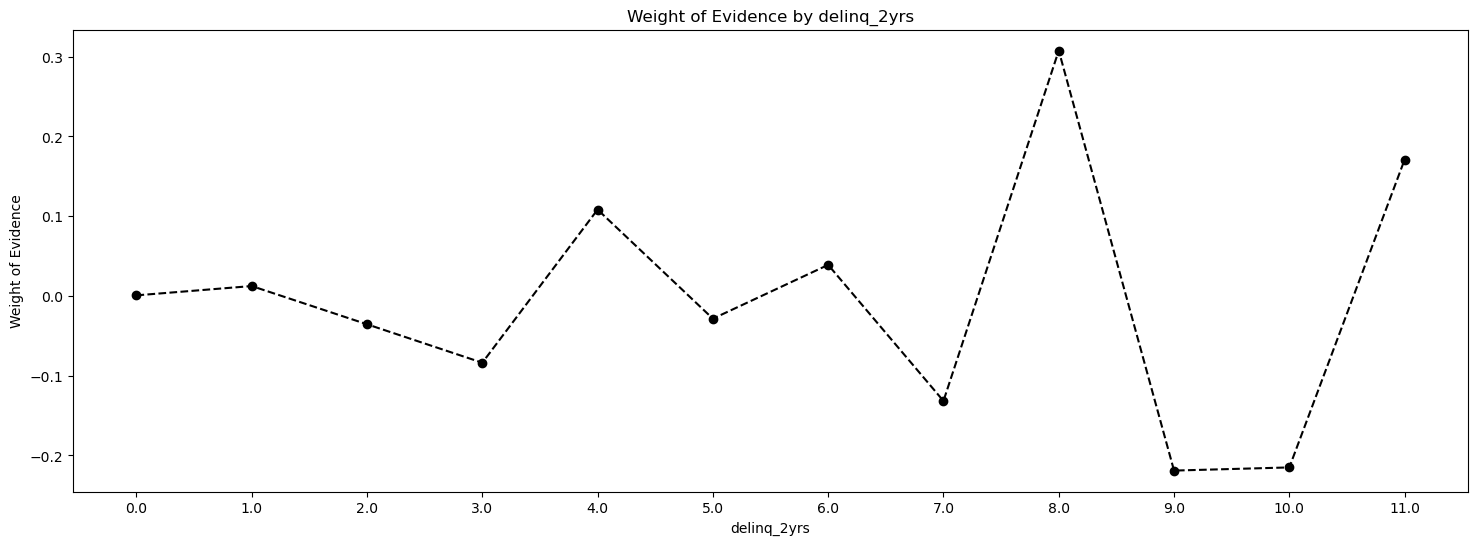

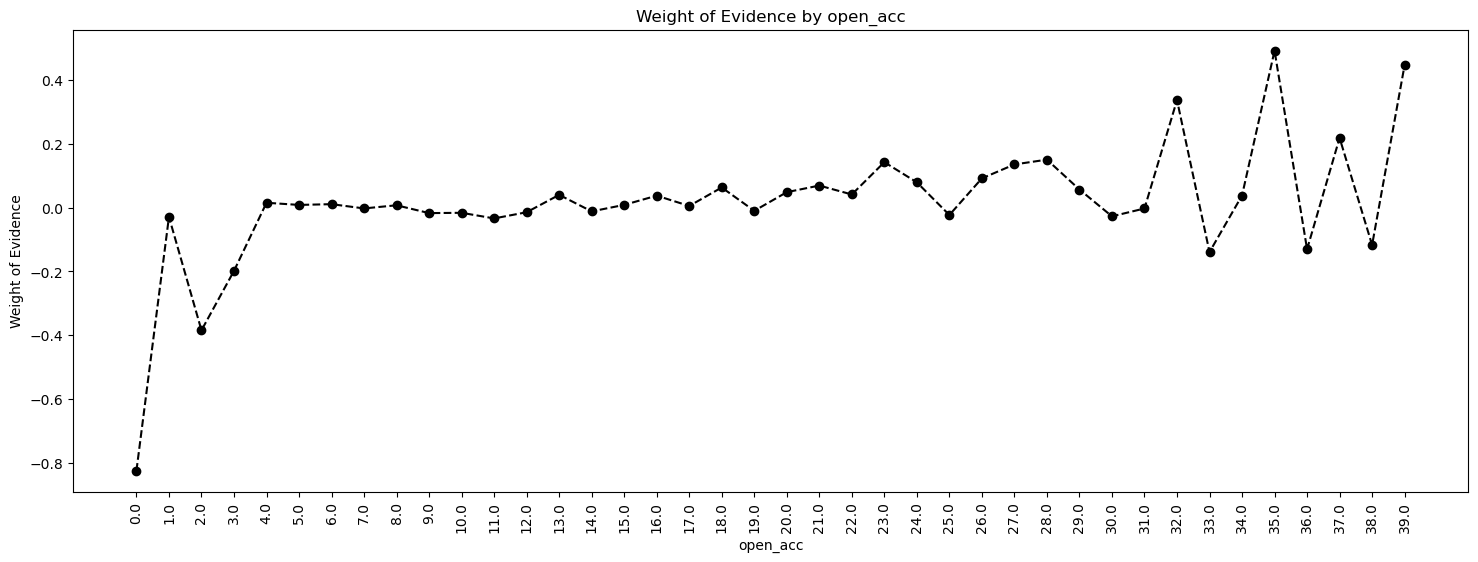

In [13]:
ordered_count_features = ["delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec"]
count_woe = {feature: woe_ordered_continuous(inputs_train, feature, target_train) for feature in ordered_count_features}
for feature, table in count_woe.items():
    display(table)
    plot_by_woe(table, rotation=90)
plot_by_woe(count_woe["delinq_2yrs"].iloc[:-12])
plot_by_woe(count_woe["open_acc"].iloc[:40], rotation=90)

In [14]:
delinq_groups = {"0": lambda x: x == 0, "1-3": lambda x: x.between(1, 3), ">=4": lambda x: x >= 4}
inq_groups = {"0": lambda x: x == 0, "1-2": lambda x: x.between(1, 2), "3-6": lambda x: x.between(3, 6), ">6": lambda x: x > 6}
open_acc_groups = {"0": lambda x: x == 0, "1-3": lambda x: x.between(1, 3), "4-12": lambda x: x.between(4, 12), "13-17": lambda x: x.between(13, 17), "18-22": lambda x: x.between(18, 22), "23-25": lambda x: x.between(23, 25), "26-30": lambda x: x.between(26, 30), ">=31": lambda x: x >= 31}
pub_rec_groups = {"0-2": lambda x: x.between(0, 2), "3-4": lambda x: x.between(3, 4), ">=5": lambda x: x >= 5}

The original notebook labelled the last delinquency band `>=4` but tested `>=9`. The condition is corrected to `>=4`, matching its label and the stated grouping.

## Total accounts and accounts currently delinquent

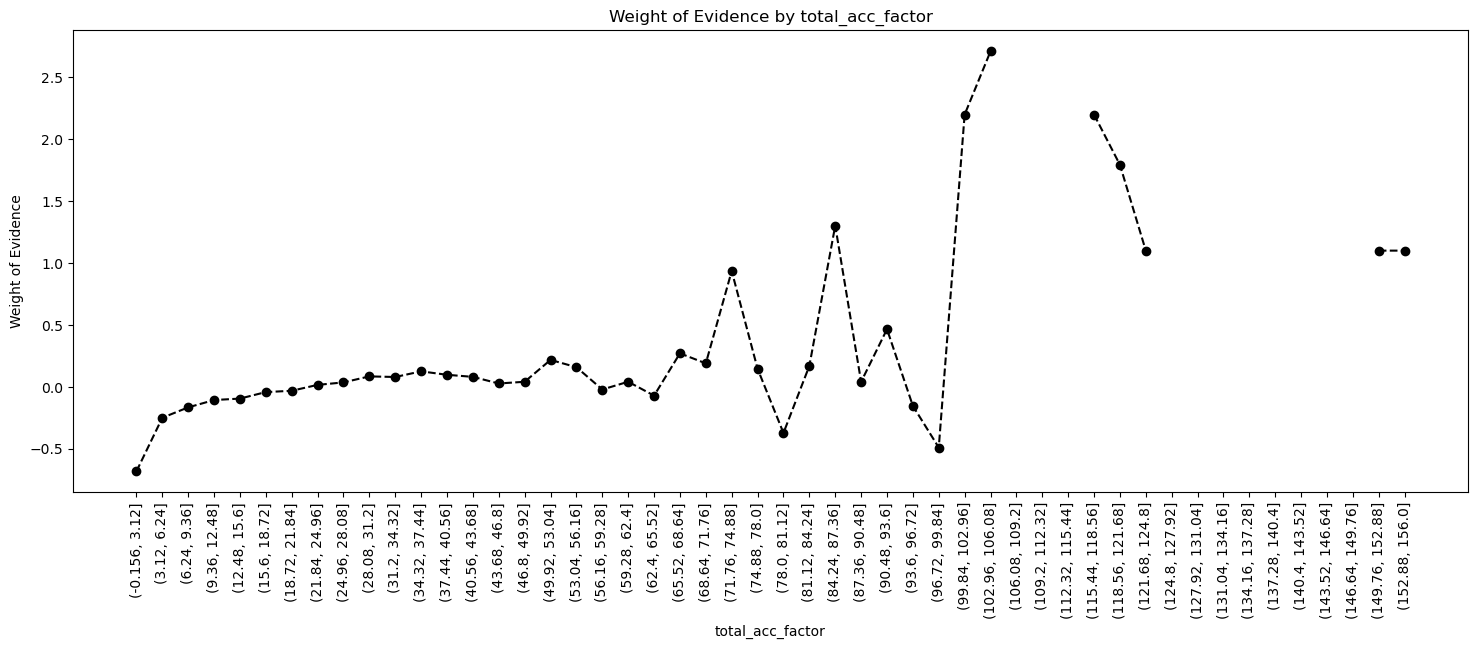

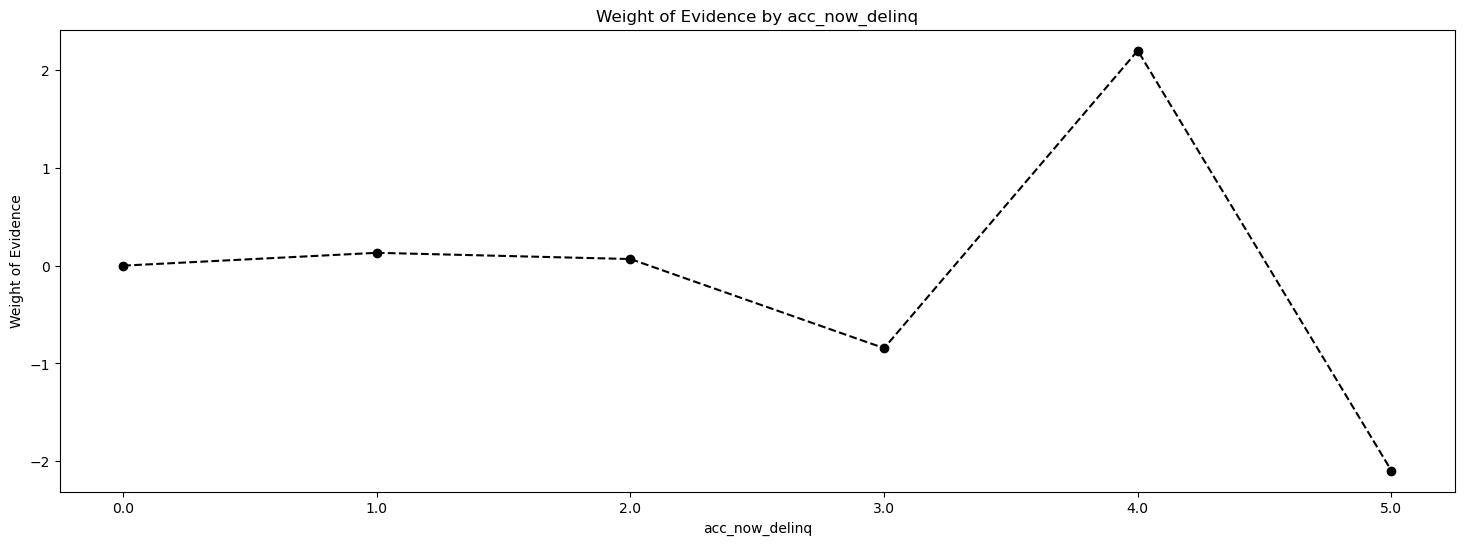

,total_acc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.156, 3.12]",487,0.804928,0.001306,392.0,95.0,0.001180,0.002330,-0.680470,NaN,NaN,0.008717
1,"(3.12, 6.24]",6006,0.864136,0.016101,5190.0,816.0,0.015621,0.020013,-0.247780,0.059208,0.432690,0.008717
2,"(6.24, 9.36]",14915,0.873684,0.039984,13031.0,1884.0,0.039220,0.046206,-0.163921,0.009548,0.083859,0.008717
3,"(9.36, 12.48]",25131,0.880068,0.067370,22117.0,3014.0,0.066567,0.073920,-0.104777,0.006384,0.059144,0.008717
4,"(12.48, 15.6]",33516,0.881310,0.089848,29538.0,3978.0,0.088902,0.097562,-0.092957,0.001242,0.011820,0.008717
5,"(15.6, 18.72]",38785,0.886683,0.103973,34390.0,4395.0,0.103505,0.107789,-0.040557,0.005373,0.052400,0.008717
6,"(18.72, 21.84]",40731,0.887751,0.109190,36159.0,4572.0,0.108829,0.112130,-0.029880,0.001068,0.010677,0.008717
7,"(21.84, 24.96]",40178,0.892404,0.107708,35855.0,4323.0,0.107914,0.106023,0.017678,0.004652,0.047558,0.008717
8,"(24.96, 28.08]",47480,0.894313,0.127283,42462.0,5018.0,0.127800,0.123069,0.037723,0.001910,0.020045,0.008717
9,"(28.08, 31.2]",29697,0.898811,0.079611,26692.0,3005.0,0.080336,0.073699,0.086231,0.004498,0.048508,0.008717


,acc_now_delinq,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,0.0,371660,0.890655,0.996333,331021.0,40639.0,0.996289,0.996689,-0.000401,NaN,NaN,0.000144
1,1.0,1286,0.902799,0.003447,1161.0,125.0,0.003494,0.003066,0.130868,0.012144,0.131270,0.000144
2,2.0,68,0.897059,0.000182,61.0,7.0,0.000184,0.000172,0.067109,0.005741,0.063760,0.000144
3,3.0,9,0.777778,0.000024,7.0,2.0,0.000021,0.000049,-0.845092,0.119281,0.912201,0.000144
4,4.0,3,1.000000,0.000008,3.0,0.0,0.000009,0.000000,2.200468,0.222222,3.045560,0.000144
5,5.0,2,0.500000,0.000005,1.0,1.0,0.000003,0.000025,-2.097855,0.500000,4.298323,0.000144


In [15]:
total_acc_fine = fine_class_table(inputs_train, "total_acc")
acc_now_delinq_woe = woe_ordered_continuous(inputs_train, "acc_now_delinq", target_train)
plot_by_woe(total_acc_fine, rotation=90)
plot_by_woe(acc_now_delinq_woe)
display(total_acc_fine)
display(acc_now_delinq_woe)

In [16]:
total_acc_groups = {"<=27": lambda x: x <= 27, "28-51": lambda x: x.between(28, 51), ">=52": lambda x: x >= 52}
acc_now_delinq_groups = {"0": lambda x: x == 0, ">=1": lambda x: x >= 1}

## Revolving high credit limit, installment, and income

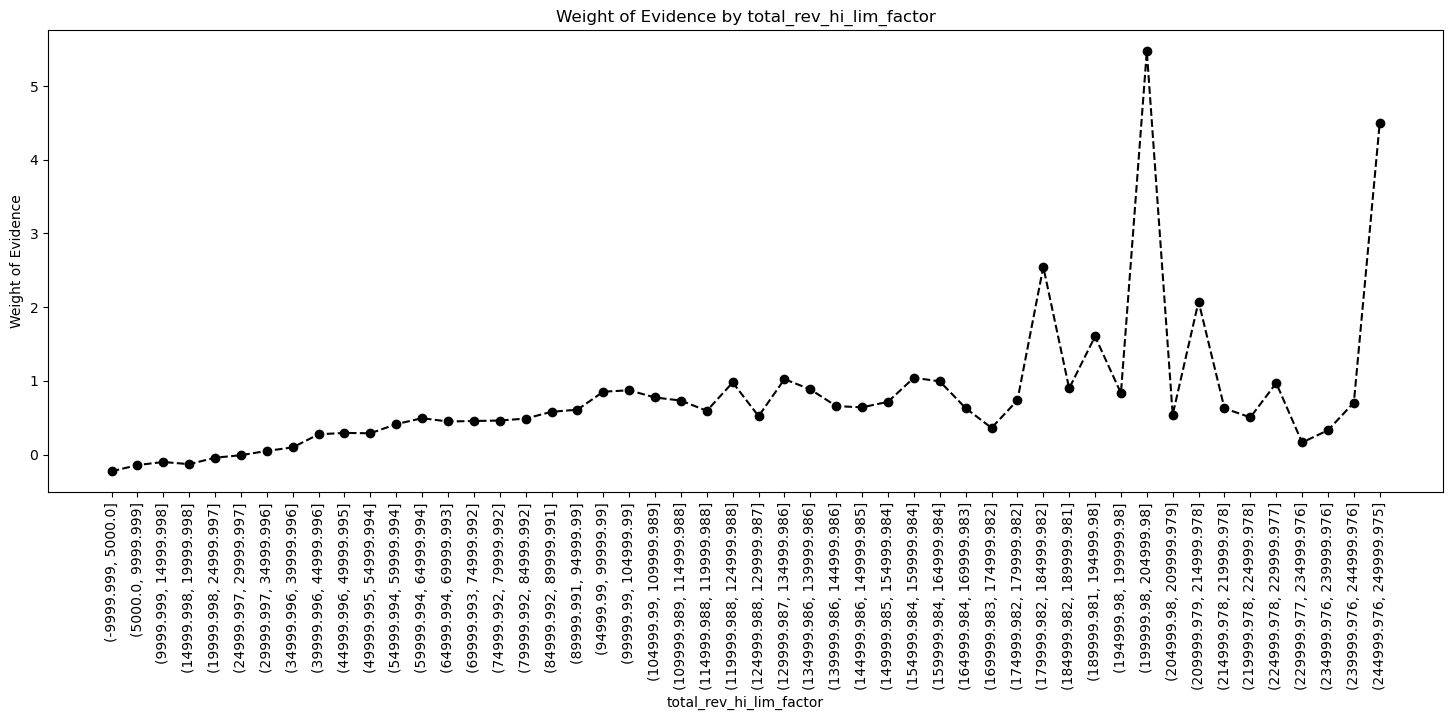

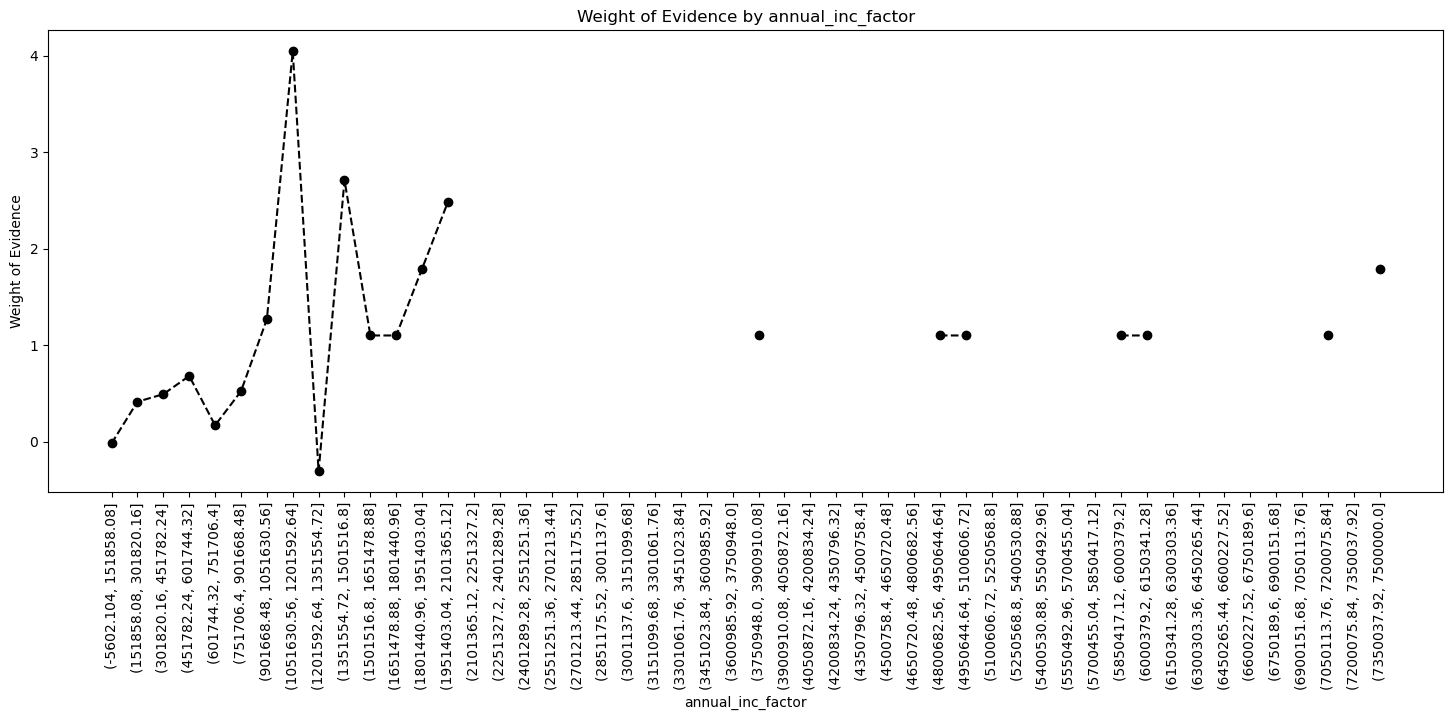

,total_rev_hi_lim_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-9999.999, 5000.0]",19466,0.866485,0.052184,16867.0,2599.0,0.050765,0.063742,-0.227623,NaN,NaN,0.04762
1,"(5000.0, 9999.999]",52690,0.876011,0.141249,46157.0,6533.0,0.138921,0.160225,-0.142673,0.009525,0.084950,0.04762
2,"(9999.999, 14999.998]",59525,0.880487,0.159572,52411.0,7114.0,0.157744,0.174474,-0.100803,0.004477,0.041869,0.04762
3,"(14999.998, 19999.998]",51408,0.877334,0.137813,45102.0,6306.0,0.135746,0.154657,-0.130430,0.003153,0.029627,0.04762
4,"(19999.998, 24999.997]",41624,0.886436,0.111584,36897.0,4727.0,0.111051,0.115932,-0.043016,0.009101,0.087414,0.04762
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,"(9974999.002, 9979999.002]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04762
1996,"(9979999.002, 9984999.002]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04762
1997,"(9984999.002, 9989999.001]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04762
1998,"(9989999.001, 9994999.0]",0,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04762


,annual_inc_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-5602.104, 151858.08]",356633,0.889079,0.956049,317075.0,39558.0,0.954315,0.970177,-0.016485,NaN,NaN,0.007381
1,"(151858.08, 301820.16]",14796,0.925047,0.039665,13687.0,1109.0,0.041194,0.027199,0.415133,0.035968,0.431617,0.007381
2,"(301820.16, 451782.24]",1076,0.930297,0.002885,1001.0,75.0,0.003013,0.001839,0.493412,0.005250,0.078279,0.007381
3,"(451782.24, 601744.32]",291,0.941581,0.000780,274.0,17.0,0.000825,0.000417,0.682060,0.011283,0.188648,0.007381
4,"(601744.32, 751706.4]",96,0.906250,0.000257,87.0,9.0,0.000262,0.000221,0.170828,0.035331,0.511231,0.007381
5,"(751706.4, 901668.48]",59,0.932203,0.000158,55.0,4.0,0.000166,0.000098,0.523184,0.025953,0.352355,0.007381
6,"(901668.48, 1051630.56]",30,0.966667,0.000080,29.0,1.0,0.000087,0.000025,1.269441,0.034463,0.746257,0.007381
7,"(1051630.56, 1201592.64]",19,1.000000,0.000051,19.0,0.0,0.000057,0.000000,4.046295,0.033333,2.776854,0.007381
8,"(1201592.64, 1351554.72]",7,0.857143,0.000019,6.0,1.0,0.000018,0.000025,-0.306096,0.142857,4.352390,0.007381
9,"(1351554.72, 1501516.8]",5,1.000000,0.000013,5.0,0.0,0.000015,0.000000,2.711293,0.142857,3.017389,0.007381


In [17]:
rev_limit_fine = fine_class_table(inputs_train, "total_rev_hi_lim", bins=2000)
annual_inc_fine = fine_class_table(inputs_train, "annual_inc")
plot_by_woe(rev_limit_fine.iloc[:50], rotation=90)
plot_by_woe(annual_inc_fine, rotation=90)
display(rev_limit_fine)
display(annual_inc_fine)

In [18]:
rev_limit_groups = {"<=5K": lambda x: x <= 5000, "5K-10K": lambda x: x.gt(5000) & x.le(10000), "10K-20K": lambda x: x.gt(10000) & x.le(20000), "20K-30K": lambda x: x.gt(20000) & x.le(30000), "30K-40K": lambda x: x.gt(30000) & x.le(40000), "40K-55K": lambda x: x.gt(40000) & x.le(55000), "55K-95K": lambda x: x.gt(55000) & x.le(95000), ">95K": lambda x: x > 95000}
annual_inc_groups = {"<=20K": lambda x: x <= 20000, "20K-30K": lambda x: x.gt(20000) & x.le(30000), "30K-40K": lambda x: x.gt(30000) & x.le(40000), "40K-50K": lambda x: x.gt(40000) & x.le(50000), "50K-60K": lambda x: x.gt(50000) & x.le(60000), "60K-70K": lambda x: x.gt(60000) & x.le(70000), "70K-80K": lambda x: x.gt(70000) & x.le(80000), "80K-90K": lambda x: x.gt(80000) & x.le(90000), "90K-100K": lambda x: x.gt(90000) & x.le(100000), "100K-120K": lambda x: x.gt(100000) & x.le(120000), "120K-140K": lambda x: x.gt(120000) & x.le(140000), ">140K": lambda x: x > 140000}

## Missingness-aware variables: recent delinquency, DTI, and public record

,mths_since_last_delinq_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.188, 3.76]",5255,0.873834,0.030437,4592.0,663.0,0.029820,0.035534,-0.175336,NaN,NaN,0.004693
1,"(3.76, 7.52]",11070,0.884914,0.064118,9796.0,1274.0,0.063613,0.068282,-0.070820,0.011080,0.104517,0.004693
2,"(7.52, 11.28]",13371,0.891257,0.077445,11917.0,1454.0,0.077387,0.077929,-0.006985,0.006343,0.063835,0.004693
3,"(11.28, 15.04]",13272,0.885398,0.076872,11751.0,1521.0,0.076309,0.081520,-0.066062,0.005859,0.059077,0.004693
4,"(15.04, 18.8]",9267,0.896622,0.053675,8309.0,958.0,0.053957,0.051345,0.049615,0.011225,0.115676,0.004693
5,"(18.8, 22.56]",11640,0.892612,0.067419,10390.0,1250.0,0.067471,0.066995,0.007068,0.004011,0.042547,0.004693
6,"(22.56, 26.32]",10918,0.895860,0.063237,9781.0,1137.0,0.063516,0.060939,0.041416,0.003248,0.034348,0.004693
7,"(26.32, 30.08]",10557,0.894099,0.061146,9439.0,1118.0,0.061295,0.059921,0.022677,0.001761,0.018740,0.004693
8,"(30.08, 33.84]",7548,0.899974,0.043718,6793.0,755.0,0.044112,0.040465,0.086298,0.005875,0.063622,0.004693
9,"(33.84, 37.6]",9720,0.899588,0.056299,8744.0,976.0,0.056782,0.052310,0.082028,0.000385,0.004270,0.004693


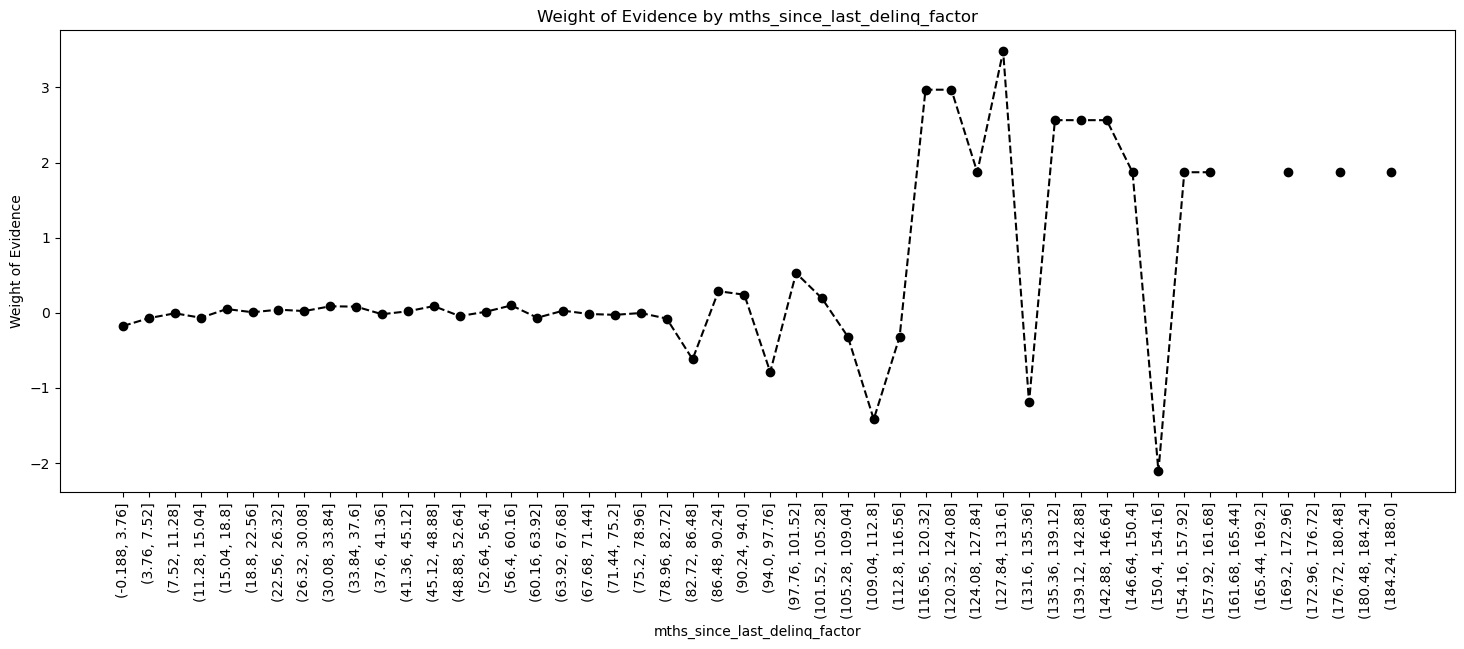

,mths_since_last_record_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.129, 2.58]",1062,0.768362,0.021184,816.0,246.0,0.018193,0.046591,-0.940359,NaN,NaN,0.082848
1,"(2.58, 5.16]",123,0.910569,0.002454,112.0,11.0,0.002497,0.002083,0.181162,0.142208,1.121521,0.082848
2,"(5.16, 7.74]",124,0.919355,0.002473,114.0,10.0,0.002542,0.001894,0.294171,0.008786,0.113010,0.082848
3,"(7.74, 10.32]",262,0.908397,0.005226,238.0,24.0,0.005306,0.004545,0.154775,0.010958,0.139397,0.082848
4,"(10.32, 12.9]",203,0.871921,0.004049,177.0,26.0,0.003946,0.004924,-0.221389,0.036476,0.376164,0.082848
5,"(12.9, 15.48]",319,0.896552,0.006363,286.0,33.0,0.006377,0.006250,0.020042,0.024631,0.241431,0.082848
6,"(15.48, 18.06]",346,0.913295,0.006902,316.0,30.0,0.007045,0.005682,0.215103,0.016743,0.195061,0.082848
7,"(18.06, 20.64]",250,0.932000,0.004987,233.0,17.0,0.005195,0.003220,0.478383,0.018705,0.263280,0.082848
8,"(20.64, 23.22]",435,0.917241,0.008677,399.0,36.0,0.008896,0.006818,0.266000,0.014759,0.212383,0.082848
9,"(23.22, 25.8]",327,0.911315,0.006523,298.0,29.0,0.006644,0.005492,0.190356,0.005926,0.075645,0.082848


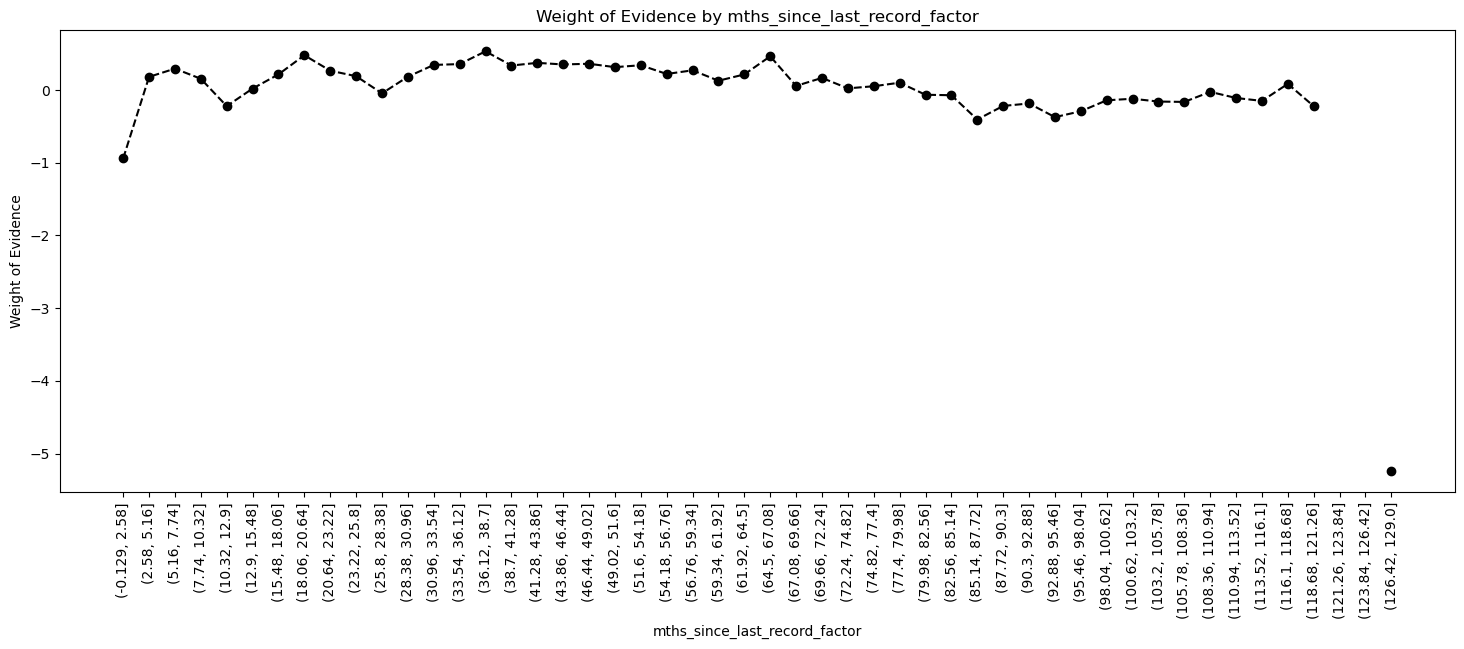

,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.04, 0.4]",749,0.878505,0.002008,658.0,91.0,0.001980,0.002232,-0.119510,NaN,NaN,0.029017
1,"(0.4, 0.8]",788,0.922589,0.002112,727.0,61.0,0.002188,0.001496,0.380198,0.044084,0.499707,0.029017
2,"(0.8, 1.2]",921,0.896851,0.002469,826.0,95.0,0.002486,0.002330,0.064863,0.025738,0.315335,0.029017
3,"(1.2, 1.6]",1045,0.907177,0.002801,948.0,97.0,0.002853,0.002379,0.181788,0.010326,0.116926,0.029017
4,"(1.6, 2.0]",1172,0.901877,0.003142,1057.0,115.0,0.003181,0.002820,0.120403,0.005300,0.061386,0.029017
5,"(2.0, 2.399]",1335,0.916105,0.003579,1223.0,112.0,0.003681,0.002747,0.292708,0.014228,0.172305,0.029017
6,"(2.399, 2.799]",1532,0.916449,0.004107,1404.0,128.0,0.004226,0.003139,0.297195,0.000344,0.004487,0.029017
7,"(2.799, 3.199]",1725,0.904348,0.004624,1560.0,165.0,0.004695,0.004047,0.148641,0.012101,0.148555,0.029017
8,"(3.199, 3.599]",1915,0.905483,0.005134,1734.0,181.0,0.005219,0.004439,0.161834,0.001135,0.013193,0.029017
9,"(3.599, 3.999]",2180,0.912385,0.005844,1989.0,191.0,0.005986,0.004684,0.245259,0.006902,0.083425,0.029017


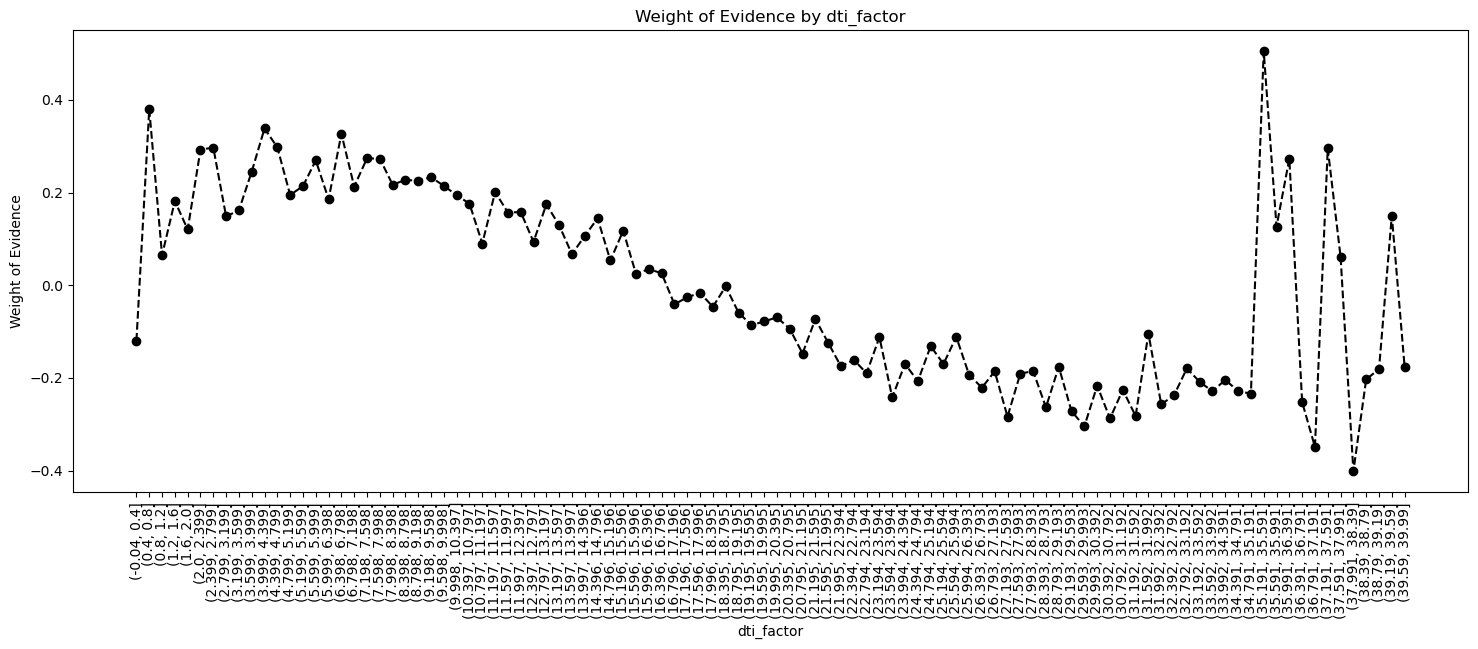

,dti_factor,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,"(-0.035, 0.7]",1346,0.898217,0.003636,1209.0,137.0,0.003667,0.003386,0.079625,NaN,NaN,0.027802
1,"(0.7, 1.4]",1664,0.897837,0.004495,1494.0,170.0,0.004531,0.004202,0.075471,0.000380,0.004154,0.027802
2,"(1.4, 2.1]",2003,0.913130,0.005411,1829.0,174.0,0.005547,0.004301,0.254527,0.015294,0.179055,0.027802
3,"(2.1, 2.8]",2575,0.912621,0.006956,2350.0,225.0,0.007127,0.005561,0.248128,0.000509,0.006399,0.027802
4,"(2.8, 3.5]",3159,0.907249,0.008534,2866.0,293.0,0.008692,0.007242,0.182557,0.005372,0.065570,0.027802
5,"(3.5, 4.2]",3826,0.915055,0.010336,3501.0,325.0,0.010618,0.008033,0.279036,0.007806,0.096479,0.027802
6,"(4.2, 4.9]",4618,0.913382,0.012475,4218.0,400.0,0.012793,0.009887,0.257709,0.001672,0.021327,0.027802
7,"(4.9, 5.6]",5340,0.909738,0.014426,4858.0,482.0,0.014734,0.011913,0.212495,0.003645,0.045214,0.027802
8,"(5.6, 6.3]",5937,0.910898,0.016038,5408.0,529.0,0.016402,0.013075,0.226704,0.001160,0.014208,0.027802
9,"(6.3, 7.0]",6566,0.913037,0.017738,5995.0,571.0,0.018182,0.014113,0.253349,0.002139,0.026646,0.027802


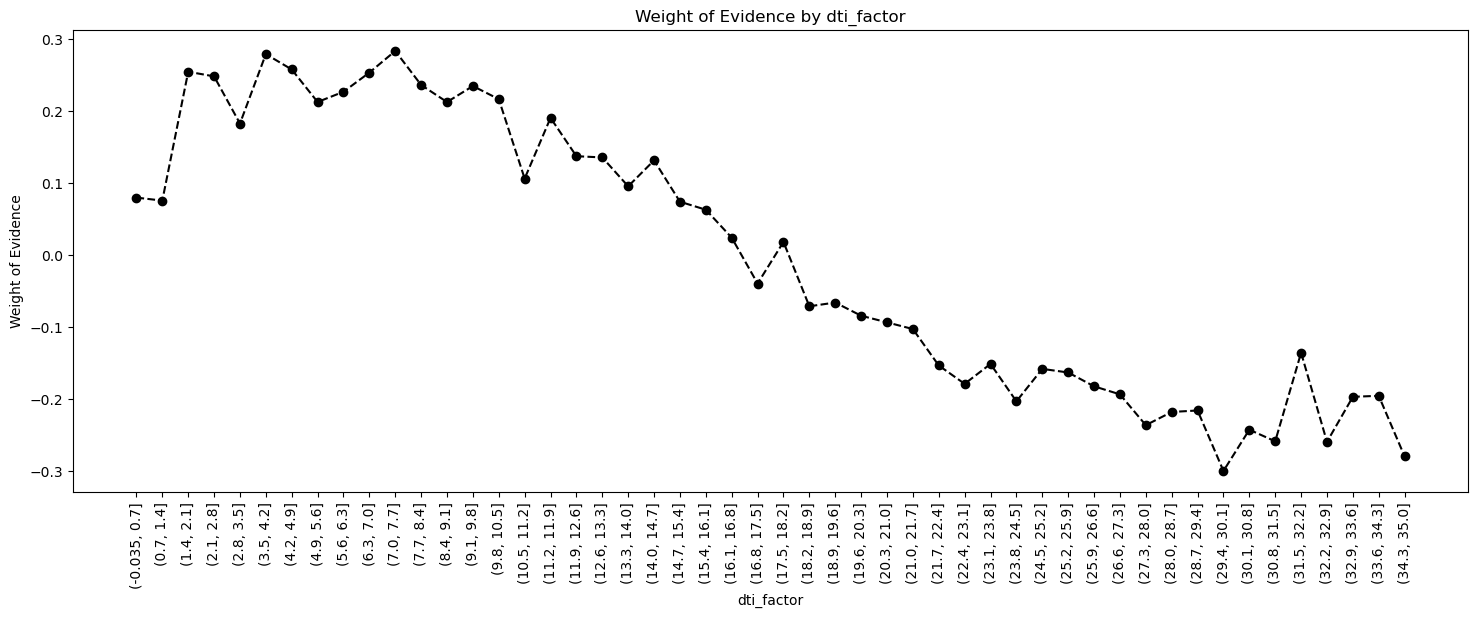

In [19]:
last_delinq_nonmissing = inputs_train.loc[inputs_train["mths_since_last_delinq"].notna()]
last_record_nonmissing = inputs_train.loc[inputs_train["mths_since_last_record"].notna()]
last_delinq_fine = fine_class_table(last_delinq_nonmissing, "mths_since_last_delinq")
last_record_fine = fine_class_table(last_record_nonmissing, "mths_since_last_record")
dti_fine = fine_class_table(inputs_train, "dti", bins=100)
dti_under_35 = fine_class_table(inputs_train.loc[inputs_train["dti"] <= 35], "dti")
for table in [last_delinq_fine, last_record_fine, dti_fine, dti_under_35]:
    display(table)
    plot_by_woe(table, rotation=90)

In [20]:
last_delinq_groups = {"Missing": lambda x: x.isna(), "0-3": lambda x: x.between(0, 3), "4-30": lambda x: x.between(4, 30), "31-56": lambda x: x.between(31, 56), ">=57": lambda x: x >= 57}
dti_groups = {"<=1.4": lambda x: x <= 1.4, "1.4-3.5": lambda x: x.gt(1.4) & x.le(3.5), "3.5-7.7": lambda x: x.gt(3.5) & x.le(7.7), "7.7-10.5": lambda x: x.gt(7.7) & x.le(10.5), "10.5-16.1": lambda x: x.gt(10.5) & x.le(16.1), "16.1-20.3": lambda x: x.gt(16.1) & x.le(20.3), "20.3-21.7": lambda x: x.gt(20.3) & x.le(21.7), "21.7-22.4": lambda x: x.gt(21.7) & x.le(22.4), "22.4-35": lambda x: x.gt(22.4) & x.le(35), ">35": lambda x: x > 35}
last_record_groups = {"Missing": lambda x: x.isna(), "0-2": lambda x: x.between(0, 2), "3-20": lambda x: x.between(3, 20), "21-31": lambda x: x.between(21, 31), "32-80": lambda x: x.between(32, 80), "81-86": lambda x: x.between(81, 86), ">86": lambda x: x > 86}

## Apply coarse classes and save final inputs

Missing-value categories are explicit where absence is informative. All boundaries below are copied from the training investigation and never re-estimated on test data.

In [21]:
continuous_groups = {"term": term_groups, "emp_length": emp_length_groups, "mths_since_issue_d": issue_groups, "int_rate": int_rate_groups, "mths_since_earliest_cr_line": earliest_groups, "delinq_2yrs": delinq_groups, "inq_last_6mths": inq_groups, "open_acc": open_acc_groups, "pub_rec": pub_rec_groups, "total_acc": total_acc_groups, "acc_now_delinq": acc_now_delinq_groups, "total_rev_hi_lim": rev_limit_groups, "annual_inc": annual_inc_groups, "mths_since_last_delinq": last_delinq_groups, "dti": dti_groups, "mths_since_last_record": last_record_groups}
source_columns = {"term": "term_int", "emp_length": "emp_length_int", "mths_since_issue_d": "mths_issue_date", "mths_since_earliest_cr_line": "mths_earliest_cr_line_date", **{key: key for key in continuous_groups if key not in {"term", "emp_length", "mths_since_issue_d", "mths_since_earliest_cr_line"}}}
model_inputs_train = inputs_train.copy()
model_inputs_test = inputs_test.copy()
for output_feature, groups in continuous_groups.items():
    source_feature = source_columns[output_feature]
    model_inputs_train = add_interval_groups(model_inputs_train, source_feature, groups, output_feature)
    model_inputs_test = add_interval_groups(model_inputs_test, source_feature, groups, output_feature)

for split_name, frame in {"train": model_inputs_train, "test": model_inputs_test}.items():
    for output_feature, groups in continuous_groups.items():
        family_columns = [f"{output_feature}:{label}" for label in groups]
        assert frame[family_columns].sum(axis=1).eq(1).all(), f"{split_name} {output_feature} groups are not exhaustive and exclusive"

model_inputs_train.to_pickle(PROCESSED / "model_inputs_train.pkl")
model_inputs_test.to_pickle(PROCESSED / "model_inputs_test.pkl")
print("Saved model checkpoints:", model_inputs_train.shape, model_inputs_test.shape)

Saved model checkpoints: (373028, 303) (93257, 303)


## Final feature inventory and conclusions

The final matrix includes the original discrete families plus coarse classes for term, employment length, issue date, interest rate, credit history, account behavior, revolving limit, income, delinquency recency, DTI, and public-record recency. Funded amount and installment are investigated and plotted; funded amount is deliberately excluded because its WoE does not supply useful monotonic discrimination. Reference categories are selected later with the logistic specification.